In [1]:
include("/Users/ndiaz/psm-nr_final/PSM-FINAL.jl")
include("/Users/ndiaz/psm-nr_final/SWPSM-FINAL.jl")
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")


using StatsPlots
using Images
using Random
using LaTeXStrings
using BM3DDenoise
using LocalFilters
using CSV 
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=1, 
    framestyle=:box, 
    label=nothing, 
    grid=true
)

In [4]:
XECheckered=  reverse(readdlm("/Users/ndiaz/Downloads/Final_Results_L8-12/SyntheticImages/Checkered/S1/Checkered.csv_FINAL10cPSM_estim0.1.tsv"),dims=1)
XEConcentric=  reverse(readdlm("/Users/ndiaz/Downloads/Final_Results_L8-12/SyntheticImages/ConcentricCircles/S1/Concentric_Circles_lambda1.csv_FINAL10cPSM_estim0.1.tsv"),dims=1)
XEDiagonal =  reverse(readdlm("/Users/ndiaz/Downloads/Final_Results_L8-12/SyntheticImages/DiagonalStripes/S1/DiagStripes.csv_FINAL10cPSM_estim0.1.tsv"),dims=1)

Diagonal_path = "/Users/ndiaz/Downloads/DiagStripes.csv"
Checkered_path = "/Users/ndiaz/Downloads/Checkered.csv";
FingerPrint_Path = "/Users/ndiaz/Downloads/DB1_B/110_5.tif";
Concentric_path_05 = "/Users/ndiaz/Downloads/Concentric_Circles_lambda05.csv";
Concentric_path_2 = "/Users/ndiaz/Downloads/Concentric_Circles_lambda2.csv";
Concentric_path_8 = "/Users/ndiaz/Downloads/Concentric_Circles_lambda8.csv";
Concentric_path_04 = "/Users/ndiaz/Downloads/Concentric_Circles_lambdap04.csv";
baboon_path = "/Users/ndiaz/Downloads/baboon.tif";
brodatz_grass_path = "/Users/ndiaz/Downloads/SIPI_brodatz_grass.tiff"
boat_path = "/Users/ndiaz/Downloads/boat_512.tiff"
couple_path = "/Users/ndiaz/Downloads/couple.tif"
peppers_path = "/Users/ndiaz/Downloads/peppers.tif"
house_path = "/Users/ndiaz/Downloads/house.tif"
brodatz_sand_path = "/Users/ndiaz/Downloads/Brodatz_Sand.tiff"
brodatz_textMosaic1_path = "/Users/ndiaz/Downloads/texmos1.p512.tiff"
plane_path = "/Users/ndiaz/Downloads/plane.tif"
man_path = "/Users/ndiaz/Downloads/man.tif"

SIPI_aerial_path = "/Users/ndiaz/Downloads/SIPI_aerial.tiff"
SEM_path = "/Users/ndiaz/Downloads/PrHu_data/Box15_N1_13500x.tif"
Barb_path = "/Users/ndiaz/Downloads/barbara.csv";

forest_path = "/Users/ndiaz/Downloads/UCMerced_LandUse/Images/forest/forest15.tif";
URU_TreeRing_path = "/Users/ndiaz/Downloads/F04a.tif";

SnowFlake1_path = "/Users/ndiaz/Downloads/i0120a001A.tif";
SnowFlake2_path = "/Users/ndiaz/Downloads/f0105a220B.tif";
SnowFlake3_path = "/Users/ndiaz/Downloads/i0120b030A.tif";

Antoine_Disk_100 = "/Users/ndiaz/Downloads/Antoine_disk_image.csv";
Antoine_Disk_512 = "/Users/ndiaz/Downloads/Antoine_disk_image_512.tiff";

# Noise Level Estimation

In [5]:
using Statistics, DataFrames, CSV
using Dates

function NLE_Experiment_Multi(paths::Vector{String}, sigmas::Vector{Float64}, patch_sizes::Vector{Int64}, n_Seeds)
    # Master folder for this run
    timestamp = Dates.format(now(), "yyyy-mm-dd_HH-MM-SS")
    main_folder_name = "NLE_Batch_Experiment_" * timestamp
    mkpath(main_folder_name)
    
    # Initialize the master DataFrame
    results_df = DataFrame(
        path = String[],
        NLE_patchSize = Int[], 
        sigma = Float64[], 
        n_Seeds = Int[], 
        mean_error = Float64[], 
        std_error = Float64[],
        bias = Float64[],
        mean_error_Classic = Float64[], 
        std_error_Classic = Float64[],
        bias_Classic = Float64[]
    )

    # Level 1: Paths (Images)
    for path in paths
        IMG_NAME = split(split(path, '/')[end], '.')[1]
        img_folder = joinpath(main_folder_name, IMG_NAME)
        mkpath(img_folder)

        # Level 2: Patch Sizes
        for ps in patch_sizes
            # Level 3: Sigmas
            for σ in sigmas
                all_errors = Float64[]
                all_errors_Classic = Float64[]
                bias = Float64[]
                bias_Classic = Float64[]
                
                # Nested folder for plots: Image/Sigma_0.05/Patch_30/
                plot_folder = joinpath(img_folder, "sigma_$σ", "patch_$ps")
                mkpath(plot_folder)
                
                # Level 4: Seeds
                for seed in 1:n_Seeds
                    W, X, Y, σe,σeClassic, Sm_idx1, Sm_idx2 = getNoisyimage(path, σ, ps, seed, true)
                    
                    # Optional: Save plot for the first seed of each combo to save disk space
                    if seed == 1
                        SmoothRegion = Y[Sm_idx1:Sm_idx1+ps-1, Sm_idx2:Sm_idx2+ps-1]
                        plt_SR = plot(image_plot(SmoothRegion, 0, 1, L"Y_{S}"))
                        savefig(joinpath(plot_folder, "Sample_Seed_$seed.png"))
                    end
                    
                    # Error calculation (epsilon)
                    epsilon = 100 * abs(σ - σe) / σ
                    epsilon_Classic = 100 * abs(σ - σeClassic) / σ
                    push!(all_errors, epsilon)
                    push!(all_errors_Classic, epsilon_Classic)
                    push!(bias, σ - σe)
                    push!(bias_Classic, σ - σeClassic)
                end
                
                # Aggregate stats for this (Path, Patch, Sigma) combo
                m_err = mean(all_errors)
                m_err_Classic = mean(all_errors_Classic)
                mean_bias = mean(bias)
                mean_bias_classic = mean(bias_Classic)
                
                s_err = std(all_errors) / sqrt(n_Seeds)
                s_err_Classic = std(all_errors_Classic) / sqrt(n_Seeds)
                
                # Add results as a new row
                push!(results_df, [path, ps, σ, n_Seeds, 
                        m_err, s_err,mean_bias,
                        m_err_Classic,s_err_Classic,mean_bias_classic
                        ])
            end
        end
        
        # Save a partial CSV after each image is processed (as a backup)
        CSV.write(joinpath(main_folder_name, "checkpoint_results.csv"), results_df)
    end
    
    # Final save
    CSV.write(joinpath(main_folder_name, "final_results.csv"), results_df)
    
    return results_df
end

#############################

NLE_Experiment_Multi (generic function with 1 method)

In [8]:
# Setup your batch parameters
path_list = [boat_path] 
sigma_list = [0.05]
patch_list = [10]
n_seeds = 2
NLE_Experiment_Multi(path_list,
                               sigma_list,
                               patch_list,
                               n_seeds)

tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.04
Size (y): (512, 512)
[331, 343]
[340, 352]tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.04
Size (y): (512, 512)
[7, 79]
[16, 88]

Row,path,NLE_patchSize,sigma,n_Seeds,mean_error,std_error,bias,mean_error_Classic,std_error_Classic,bias_Classic
,String,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,/Users/ndiaz/Downloads/boat_512.tiff,10,0.04,2,16.4384,8.55918,0.00657537,30.9918,4.72805,0.0123967


In [10]:

include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")

# Setup your batch parameters
path_list = [boat_path, house_path, peppers_path, Barb_path, couple_path,plane_path,man_path] 
sigma_list = [0.025, 0.05, 0.1,0.2,0.3]
patch_list = [16,32,40,45,50]
n_seeds = 40

# Run the batch experiment
NLE_EXP = NLE_Experiment_Multi(path_list,
                               sigma_list,
                               patch_list,
                               n_seeds)

tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.025
Size (y): (512, 512)
[349, 493]
[364, 508]tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.025
Size (y): (512, 512)
[1, 79]
[16, 94]tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.025
Size (y): (512, 512)
[361, 307]
[376, 322]tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.025
Size (y): (512, 512)
[319, 493]
[334, 508]tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.025
Size (y): (512, 512)
[355, 301]
[370, 316]tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Im

Excessive output truncated after 524288 bytes.


[343, 349]
[392, 398]tif
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.2
Size (y): (512

Row,path,NLE_patchSize,sigma,n_Seeds,mean_error,std_error,bias,mean_error_Classic,std_error_Classic,bias_Classic
,String,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,/Users/ndiaz/Downloads/boat_512.tiff,16,0.025,40,10.5234,0.86275,0.00256312,14.5808,0.540684,0.00364521
2,/Users/ndiaz/Downloads/boat_512.tiff,16,0.05,40,13.3291,0.784468,0.00666455,18.9016,0.414565,0.00945081
3,/Users/ndiaz/Downloads/boat_512.tiff,16,0.1,40,15.9093,0.810792,0.0159093,20.8229,0.324347,0.0208229
4,/Users/ndiaz/Downloads/boat_512.tiff,16,0.2,40,17.3533,0.8565,0.0347065,22.1954,0.427702,0.0443909
5,/Users/ndiaz/Downloads/boat_512.tiff,16,0.3,40,17.0699,0.795975,0.0512096,22.5789,0.42417,0.0677366
6,/Users/ndiaz/Downloads/boat_512.tiff,32,0.025,40,2.55181,0.304387,6.7643e-5,2.71492,0.283817,0.000667
7,/Users/ndiaz/Downloads/boat_512.tiff,32,0.05,40,3.92511,0.300782,0.00181689,6.20402,0.225942,0.00310201
8,/Users/ndiaz/Downloads/boat_512.tiff,32,0.1,40,6.3237,0.341834,0.00614525,8.75282,0.238455,0.00875282
9,/Users/ndiaz/Downloads/boat_512.tiff,32,0.2,40,7.46741,0.356665,0.0149348,10.0478,0.216191,0.0200957


In [3]:
using DataFrames
NLE_EXP = CSV.read("/Users/ndiaz/Final_cPSM2D/SinusoidalFits/NLE_Batch_Experiment_2026-03-11_02-00-05/final_results.csv", DataFrame)

Row,path,NLE_patchSize,sigma,n_Seeds,mean_error,std_error,bias,mean_error_Classic,std_error_Classic,bias_Classic
,String,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,/Users/ndiaz/Downloads/boat_512.tiff,16,0.025,40,10.5234,0.86275,0.00256312,14.5808,0.540684,0.00364521
2,/Users/ndiaz/Downloads/boat_512.tiff,16,0.05,40,13.3291,0.784468,0.00666455,18.9016,0.414565,0.00945081
3,/Users/ndiaz/Downloads/boat_512.tiff,16,0.1,40,15.9093,0.810792,0.0159093,20.8229,0.324347,0.0208229
4,/Users/ndiaz/Downloads/boat_512.tiff,16,0.2,40,17.3533,0.8565,0.0347065,22.1954,0.427702,0.0443909
5,/Users/ndiaz/Downloads/boat_512.tiff,16,0.3,40,17.0699,0.795975,0.0512096,22.5789,0.42417,0.0677366
6,/Users/ndiaz/Downloads/boat_512.tiff,32,0.025,40,2.55181,0.304387,6.7643e-5,2.71492,0.283817,0.000667
7,/Users/ndiaz/Downloads/boat_512.tiff,32,0.05,40,3.92511,0.300782,0.00181689,6.20402,0.225942,0.00310201
8,/Users/ndiaz/Downloads/boat_512.tiff,32,0.1,40,6.3237,0.341834,0.00614525,8.75282,0.238455,0.00875282
9,/Users/ndiaz/Downloads/boat_512.tiff,32,0.2,40,7.46741,0.356665,0.0149348,10.0478,0.216191,0.0200957


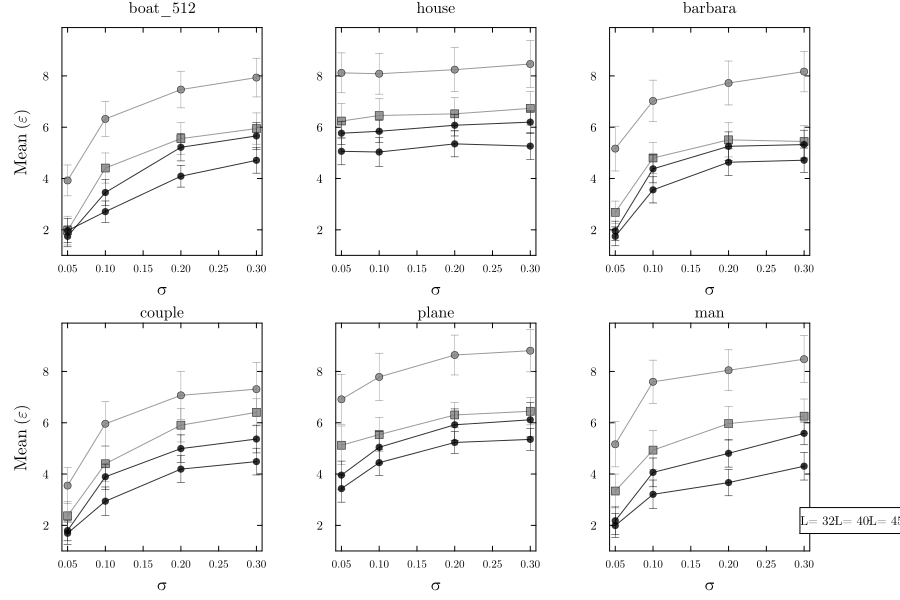

In [47]:
# using Plots, Statistics, DataFrames

# """
#     visualize_nle_results(df)

# Expects a DataFrame `df` with columns:
# - :sigma (Actual noise level)
# - :mean_error (Measured error)
# - :std_error (Standard deviation of error)
# - :NLE_patchSize (The NLE patch size used)
# - :path (The image path/type)
# """
# function visualize_nle_results(df::DataFrame)
#     # 1. Filter out sigma = 0.025 and "peppers"
#     filtered_df = filter(row -> row.sigma != 0.025 && 
#                                 !occursin("peppers", lowercase(row.path)), df)

#     # Get unique paths and patch sizes
#     paths = unique(filtered_df.path)
#     patch_sizes = sort(unique(filtered_df.NLE_patchSize))
    
#     # Define distinct markers
#     available_markers = [:circle :rect :diamond :utriangle :xcross :star5 :cross]
    
#     # Create a 2x3 layout
#     # Increased bottom_margin to prevent the legend from clipping
#     p = plot(layout = (2, 3), size = (1200, 800), 
#              link = :all, margin = 7Plots.mm,
#              bottom_margin = 25Plots.mm)

#     for (i, path) in enumerate(paths)
#         sub_df = filter(row -> row.path == path, filtered_df)
#         img_name = split(split(path, '/')[end], '.')[1]

#         plot!(p[i], 
#             sub_df.sigma, 
#             sub_df.mean_error, 
#             yerror = 2 .* sub_df.std_error,
#             group = sub_df.NLE_patchSize,
            
#             # Styling: All black with distinct markers
#             linecolor = :black,
#             markercolor = :black,
#             markershape = available_markers, 
            
#             title = "$img_name",
#             xlabel = "σ",
#             ylabel = (i % 3 == 1) ? "Mean Error" : "", 
            
#             # Legend Configuration:
#             # We only enable the legend for the very last subplot (i == 6).
#             # :outerbottom places it outside the entire 2x3 grid.
#             legend = (i == length(paths)) ? :outerbottom : false,
#             legend_columns = length(patch_sizes), # Spread markers horizontally
            
#             markerstrokewidth = 0.5,
#             markersize = 5,
#             alpha = 0.7
#         )
        
#         # Reference line at zero
#         hline!(p[i], [0], color = :gray, linestyle = :dash, label = "")
#     end
    
#     return p
# end

using Plots, Statistics, DataFrames

"""
    visualize_nle_results(df)
"""
function visualize_nle_results(df::DataFrame)
    # 1. Filter out sigma = 0.025 and "peppers"
    # filtered_df = filter(row -> row.sigma != 0.025 && 
    #                             !occursin("peppers", lowercase(row.path)), df)

    filtered_df = filter(row -> row.sigma != 0.025 && 
                            row.NLE_patchSize != 16 && 
                            !occursin("peppers", lowercase(row.path)), df)

    paths = unique(filtered_df.path)
    patch_sizes = sort(unique(filtered_df.NLE_patchSize))
    available_markers = [:circle :rect :circle :circle]
    available_colors = [:gray :gray :black :black :black]
    
    # 2. Define the layout: A 2x3 grid (top) and a thin strip for the legend (bottom)
    # The 'h{0.05}' gives the legend area 5% of the total height.
    my_layout = @layout [
        Plots.grid(2, 3) legend_area{0.01w}
    ]

    # Initialize plot with the custom layout
    p = plot(layout = my_layout, size = (900, 600), 
             link = :all, margin = 5Plots.mm)

    # 3. Plot the data into the first 6 subplots
    for (i, path) in enumerate(paths)
        sub_df = filter(row -> row.path == path, filtered_df)
        img_name = split(split(path, '/')[end], '.')[1]

        plot!(p[i], 
            sub_df.sigma, 
            sub_df.mean_error, 
            yerror = 2 .* sub_df.std_error,
            group = sub_df.NLE_patchSize,
            linecolor = available_colors,
            markercolor = available_colors,
            markershape = available_markers, 
            title = "$img_name",
            xlabel = "σ",
            ylabel = (i % 3 == 1) ? "Mean "*L"(\epsilon)" : "", 
            legend = false, # Keep legend off inside the subplots
            markerstrokewidth = 0.5,
            markersize = 4,
            alpha = 0.8,
            grid=false,
            top_margin = -1Plots.mm,      # Reduces space at the top
            bottom_margin = 2Plots.mm     # Keeps some room at the bottom
        )
        plot!(xtickfontsize=7)
        plot!(titlefontsize=10)
        #hline!(p[i], [0], color = :gray, linestyle = :dash, label = "")
    end
    
    # 4. Create a "dummy" plot for the 7th subplot (the legend area)
    # We plot nothing, but enable the legend here.
    plot!(p[7], 
        fill(0, 0, length(patch_sizes)), # Empty data points
        label = reshape(["L= $s" for s in patch_sizes], 1, :),
        linecolor = available_colors,
        markercolor = available_colors,
        msc=available_colors,
        markershape = available_markers,
        legend = :bottom,
        legend_columns = length(patch_sizes),
        framestyle = :none,   # Hide axes
        grid = false,         # Hide grid
        ticks = false         # Hide ticks
    )
    
    return p
end

# visualize_nle_results(NLE_EXP)

visualize_nle_results(NLE_EXP)

In [23]:
NLE_EXP

Row,path,NLE_patchSize,sigma,n_Seeds,mean_error,std_error,bias,mean_error_Classic,std_error_Classic,bias_Classic
,String,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,/Users/ndiaz/Downloads/boat_512.tiff,16,0.025,40,10.5234,0.86275,0.00256312,14.5808,0.540684,0.00364521
2,/Users/ndiaz/Downloads/boat_512.tiff,16,0.05,40,13.3291,0.784468,0.00666455,18.9016,0.414565,0.00945081
3,/Users/ndiaz/Downloads/boat_512.tiff,16,0.1,40,15.9093,0.810792,0.0159093,20.8229,0.324347,0.0208229
4,/Users/ndiaz/Downloads/boat_512.tiff,16,0.2,40,17.3533,0.8565,0.0347065,22.1954,0.427702,0.0443909
5,/Users/ndiaz/Downloads/boat_512.tiff,16,0.3,40,17.0699,0.795975,0.0512096,22.5789,0.42417,0.0677366
6,/Users/ndiaz/Downloads/boat_512.tiff,32,0.025,40,2.55181,0.304387,6.7643e-5,2.71492,0.283817,0.000667
7,/Users/ndiaz/Downloads/boat_512.tiff,32,0.05,40,3.92511,0.300782,0.00181689,6.20402,0.225942,0.00310201
8,/Users/ndiaz/Downloads/boat_512.tiff,32,0.1,40,6.3237,0.341834,0.00614525,8.75282,0.238455,0.00875282
9,/Users/ndiaz/Downloads/boat_512.tiff,32,0.2,40,7.46741,0.356665,0.0149348,10.0478,0.216191,0.0200957


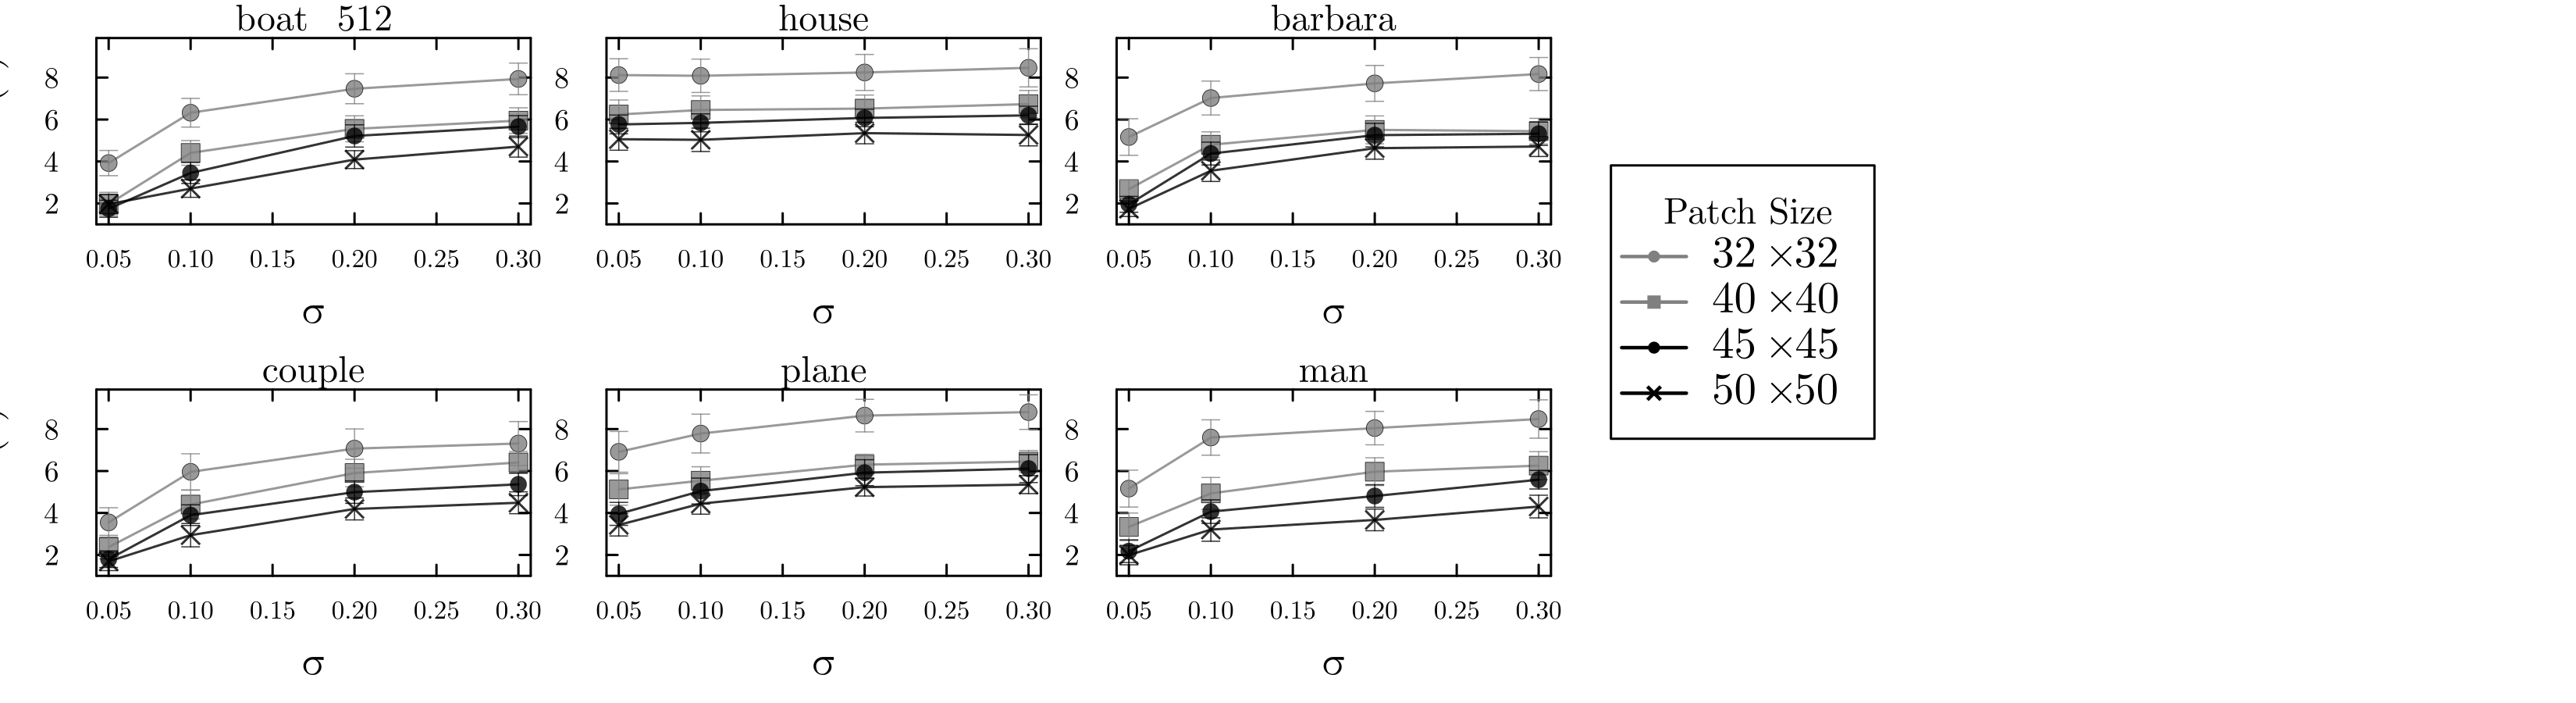

In [100]:
using Plots, Statistics, DataFrames, LaTeXStrings

function visualize_nle_results(df::DataFrame)
    # 1. Filtering
    filtered_df = filter(row -> row.sigma != 0.025 && 
                                row.NLE_patchSize != 16 && 
                                !occursin("peppers", lowercase(row.path)), df)

    paths = unique(filtered_df.path)
    patch_sizes = sort(unique(filtered_df.NLE_patchSize))
    available_markers = [:circle :rect :circle :xcross]
    available_colors = [:gray :gray :black :black :black]
    
    # 2. Updated Layout: 2x3 grid on the left, thin legend strip on the right {0.1w}
    my_layout = @layout [
        Plots.grid(2, 3) legend_area{0.4w}
    ]

    p = plot(layout = my_layout, size = (1100, 300), 
              link = :all, 
    #    margin = 5Plots.mm
    )

    # 3. Plot data into subplots 1-6
    for (i, path) in enumerate(paths)
        sub_df = filter(row -> row.path == path, filtered_df)
        img_name = split(split(path, '/')[end], '.')[1]

        plot!(p[i], 
            sub_df.sigma, 
            sub_df.mean_error, 
            yerror = 2 .* sub_df.std_error,
            group = sub_df.NLE_patchSize,
            linecolor = available_colors,
            markercolor = available_colors,
            markershape = available_markers, 
            title = "$img_name",
            xlabel = "σ",
            ylabel = (i % 3 == 1) ? "Mean "* L"(\epsilon)" : "", 
            legend = false,
            markerstrokewidth = 0.5,
            markersize = 4,
            alpha = 0.8,
            grid = false,
            top_margin = 0.0Plots.mm,
            bottom_margin = 7Plots.mm,
            right_margin = -2Plots.mm,
            xtickfontsize = 7,
            titlefontsize = 10,
            dpi=300
        )
    end
    
# 4. Vertical Legend in the 7th subplot
    # Use a 1xN matrix of NaNs to match the 1xN labels
# 4. Vertical Legend in the 7th subplot
    # Ensure dummy_data is a 1xN Row Matrix
    dummy_data = fill(NaN, 1, length(patch_sizes))

    plot!(p[7], 
        dummy_data, 
        label = reshape([" $s " *L"\times "* "$s" for s in patch_sizes], 1, :),
        linecolor = available_colors,
        markercolor = available_colors,
        msc = available_colors,
        markershape = available_markers,
        
        # Legend Styling
        legend = :left,
        legend_title = "Patch Size", # Adds the legend title
        legend_columns = 1,          # Vertical orientation
        legendfontsize = 12,          # Adjust text size
        legendtitlefontsize = 10,    # Adjust title size
        
        # Make the legend lines and markers "Larger"
        linewidth = 1,               # Thicker lines in the legend
        markersize = 600,              # Larger markers in the legend
        markerstrokewidth = 40,
        
        framestyle = :none,
        grid = false,
        ticks = false
    )
    
    return p
end

visualize_nle_results(NLE_EXP)
#savefig("NLE_2D_PATCH")